# Notebook - Comparação algoritmos
## 1. Importação das bibliotecas
Bibliotecas numpy e pandas importadas para trabalhar com dados, matplot para trabalhar com gráficos.

Usa scipy para calcular média e intervalo de confianã 95% usando distribuição de Student

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.stats import t
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

def media_ic(series, alpha=0.05):
    n = len(series)
    media = series.mean()
    desvio = series.std(ddof=1)
    erro = t.ppf(1 - alpha/2, n-1) * desvio / np.sqrt(n)
    return pd.Series({
        "media": media,
        "ic": erro
    })

## 2. Carregar os Dados
Carregar 10000000.csv para dados gerais

In [2]:
all_data = pd.read_csv("../results/10000000.csv")
all_data.head()

,vector_type,algorithm,size,time_ms,stress,carga,ram_kb_max,ram_kb_media,energy_j,comparisons,swaps
0,endnoise,HeapSort,10000000,703.818,none,0.0,43112,42886,12.84420,446056168,232185536
1,endnoise,MergeSort,10000000,508.425,none,0.0,81968,49241,8.68302,119525953,0
2,endnoise,QuickSort,10000000,368.159,none,0.0,43132,42938,8.07957,530500174,161104803
3,ordered,HeapSort,10000000,617.532,none,0.0,43128,42934,14.37630,445162673,231881708
4,ordered,MergeSort,10000000,501.121,none,0.0,81968,48527,9.24516,118788160,0


## 3. Comparação sem estresse
Comparação da performance dos sorting em ambiente sem estresse

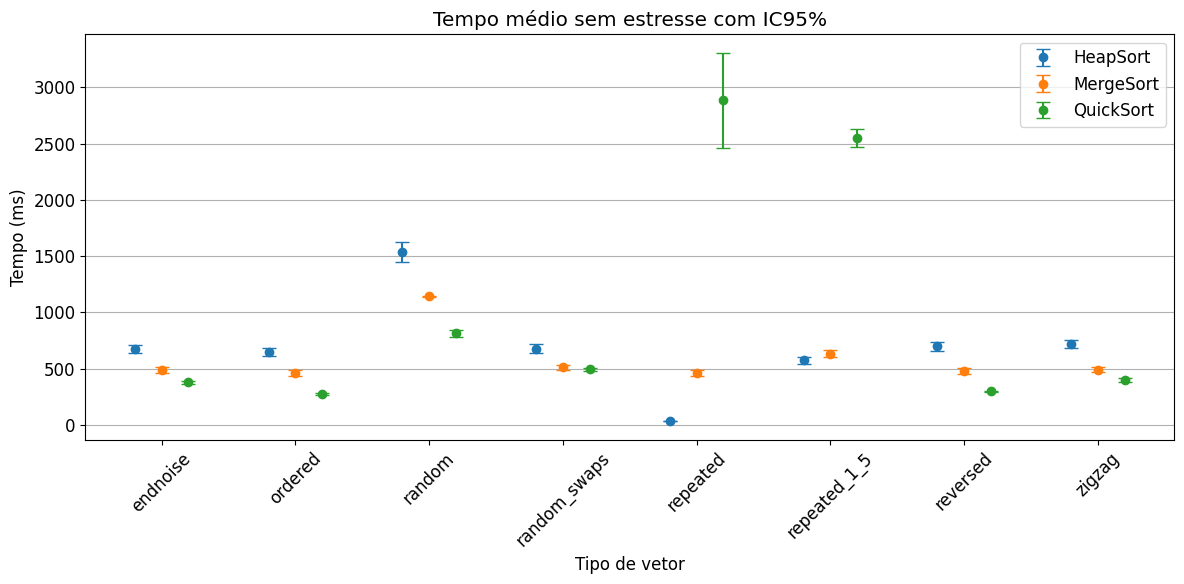

In [3]:
none = all_data[all_data["stress"] == "none"]

tempo = (
    none
    .groupby(["algorithm", "vector_type"])["time_ms"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = tempo["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(tempo["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = tempo[tempo["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")
plt.title("Tempo médio sem estresse com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Usando IC de 95% podemos afirmar com grande que quicksort é o algoritmo mais rápido nos vetores endnoise, ordered, random, reversed e zig-zag. É possível ver também que quicksort degenera fortemente em vetores com muitas repetições.

Mergesort é o mais consistente de todos, apresentando somente tempo maior num vetor randomizado, mas mostra que é o vetor mais resistente à entradas específicas de todas.

Heapsort geralmente é o mais lento, com exeção de repeated e repeated_1_5, indicando que ele lida muito bem com vetores com muitos itens repitidos. Não podemos afirmar que ele é mais rápido que merge em repeated_1_5 pois os intervalos se cruzam.

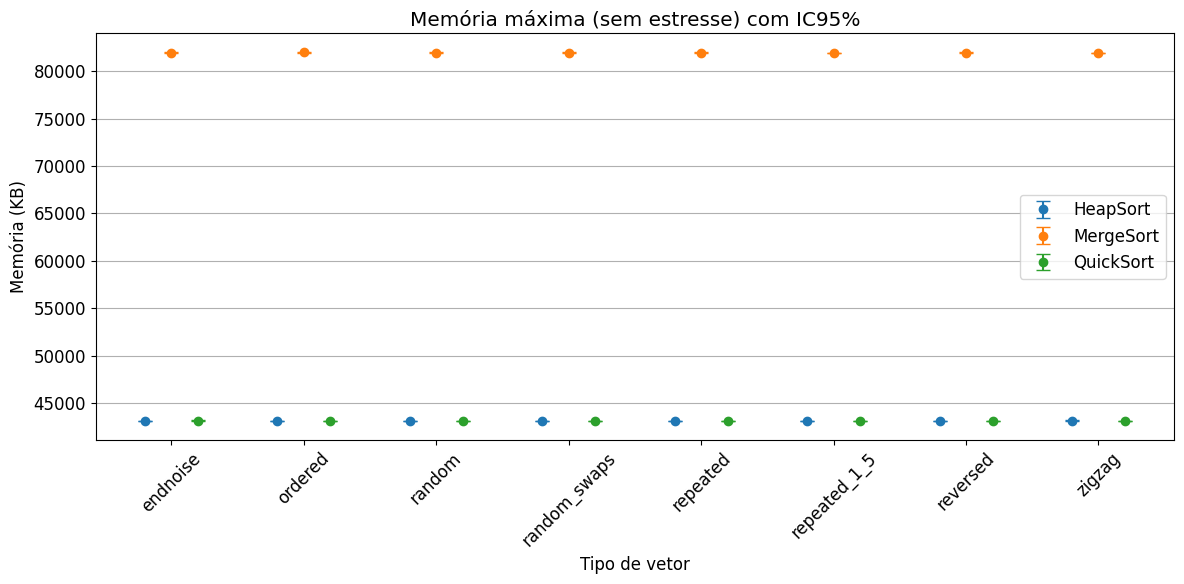

In [4]:
memoria_pico = (
    none
    .groupby(["algorithm", "vector_type"])["ram_kb_max"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = memoria_pico["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(memoria_pico["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = memoria_pico[memoria_pico["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Memória (KB)")
plt.xlabel("Tipo de vetor")
plt.title("Memória máxima (sem estresse) com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Vemos que o uso de memória dos algoritmos é extremamentes constante (quase nenhuma variação) e que mergesort usa muito mais memória do que os outros 2 algoritmos.

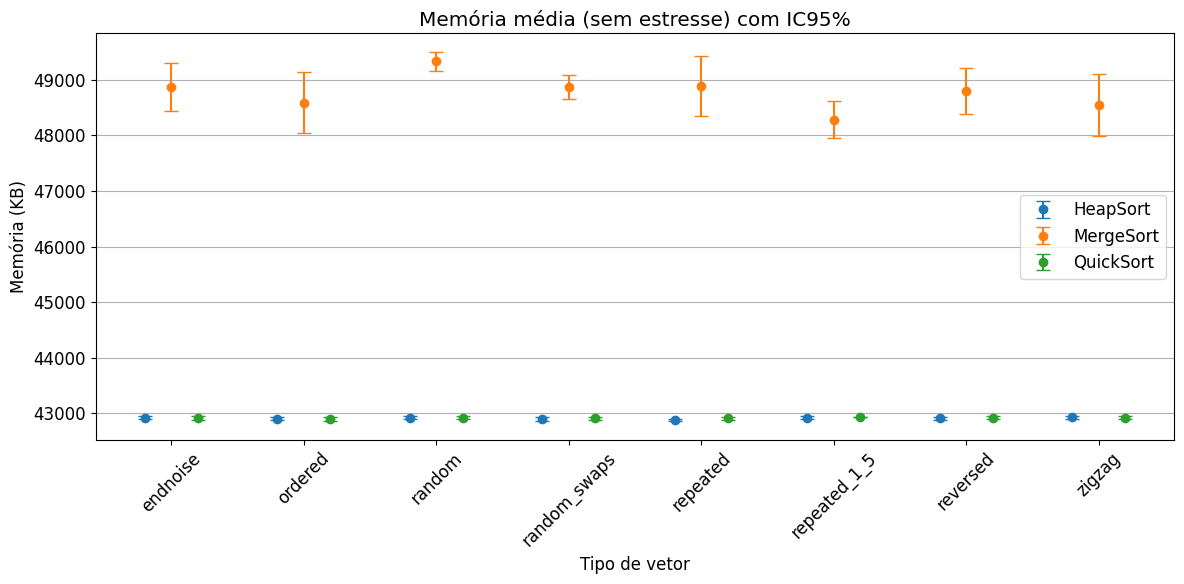

In [5]:
memoria_media = (
    none
    .groupby(["algorithm", "vector_type"])["ram_kb_media"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = memoria_media["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(memoria_media["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = memoria_media[memoria_media["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Memória (KB)")
plt.xlabel("Tipo de vetor")
plt.title("Memória média (sem estresse) com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Heap e Quick continuam sendo muito parecidos no uso médio da memória. Mergesort apresenta maior variação (aproximadamente 1MB em alguns casos), no uso médio da memória.

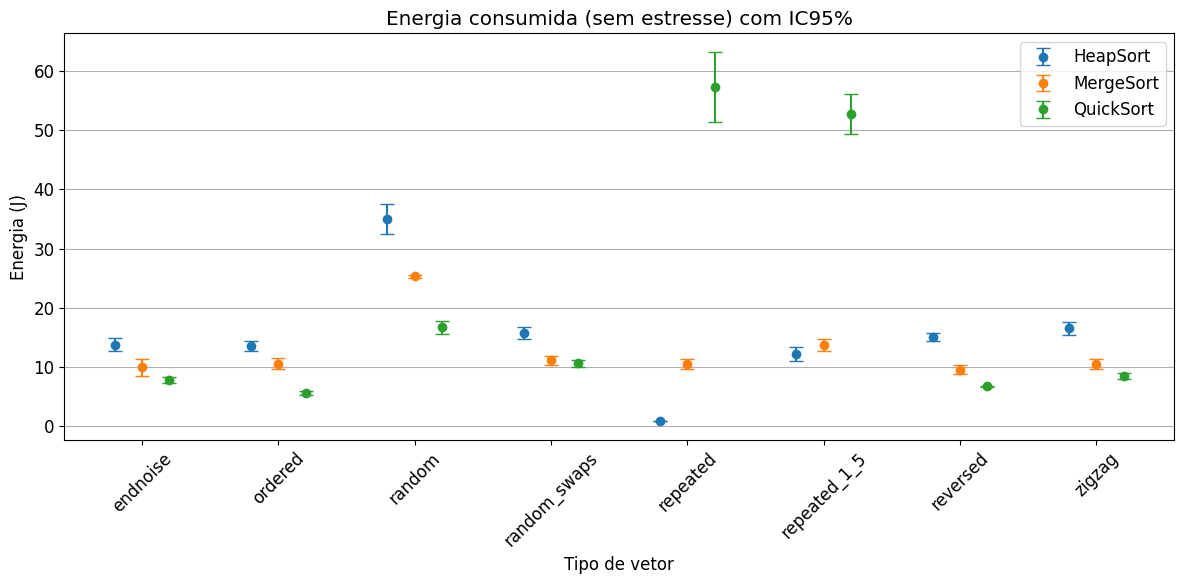

In [6]:
energia = (
    none
    .groupby(["algorithm", "vector_type"])["energy_j"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = energia["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(energia["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = energia[energia["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Energia (J)")
plt.xlabel("Tipo de vetor")
plt.title("Energia consumida (sem estresse) com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Energia quase congruente a tempo de execução

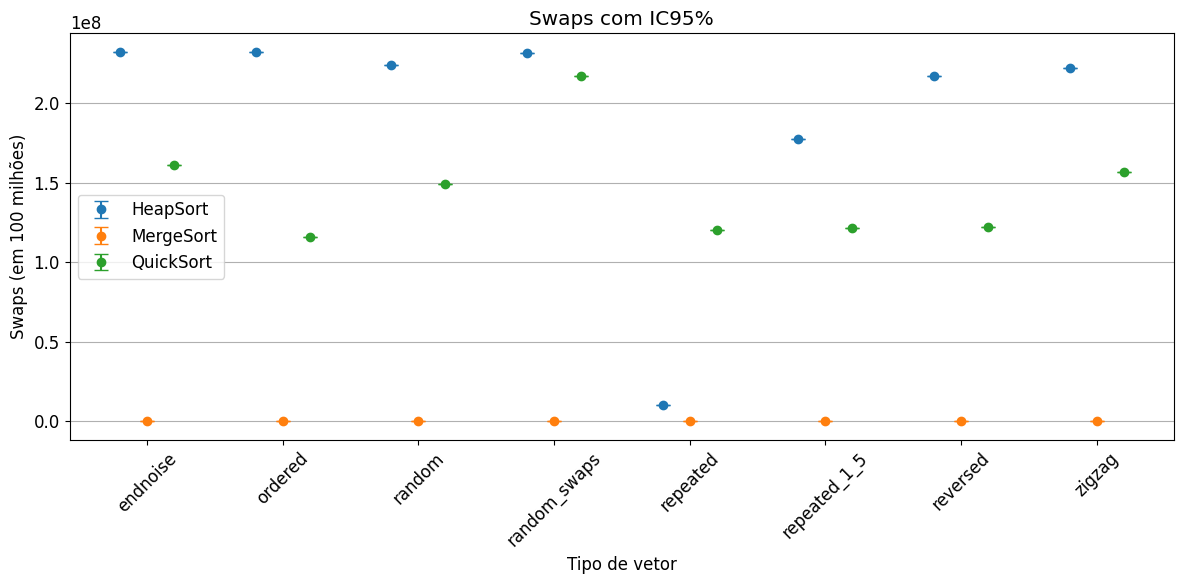

In [7]:
swaps = (
    none
    .groupby(["algorithm", "vector_type"])["swaps"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = swaps["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(swaps["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = swaps[swaps["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Swaps (em 100 milhões)")
plt.xlabel("Tipo de vetor")
plt.title("Swaps com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Heapsort realiza mais swaps que Quicksort, o que ajuda a explicar porque ele é mais lento em geral (com exceção do caso repeated).

Mergesort tradicional não realiza swaps, o que é refeltido no gráfico.

Notamos também variância 0 nos swaps, o que é bom pois indica que os algoritmos estão determinísticos quando providos com os mesmos vetores que é o comportamento esperado.

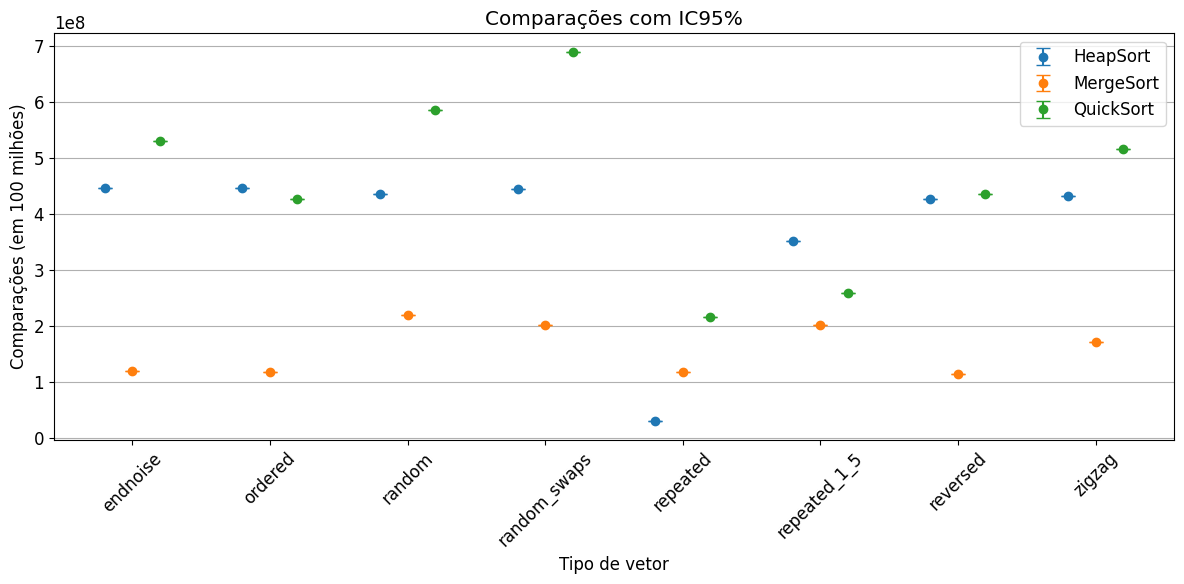

In [8]:
comparisons = (
    none
    .groupby(["algorithm", "vector_type"])["comparisons"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

plt.figure(figsize=(12,6))

algoritmos = comparisons["algorithm"].unique()
offsets = [-0.2, 0.0, 0.2]
x = np.arange(len(comparisons["vector_type"].unique()))

for alg, offset in zip(algoritmos, offsets):
    dados = comparisons[comparisons["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",   # sem linha
        capsize=5,
        label=alg
    )

plt.xticks(x, dados["vector_type"], rotation=45)

plt.ylabel("Comparações (em 100 milhões)")
plt.xlabel("Tipo de vetor")
plt.title("Comparações com IC95%")
plt.grid(True, axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Podemos ver que com exceção do caso repeated, Mergesort realiza muito menos comparações que o resto.

Também podemos ver que há casos onde o Quicksort realiza mais comparações e outros onde o Heap realiza mais comparações.

Comparações também tem variância 0, que comprova que quando recebem o mesmo vetor os algoritmos se comportam de forma determinística.


## 3. Slowdown por nível de estresse

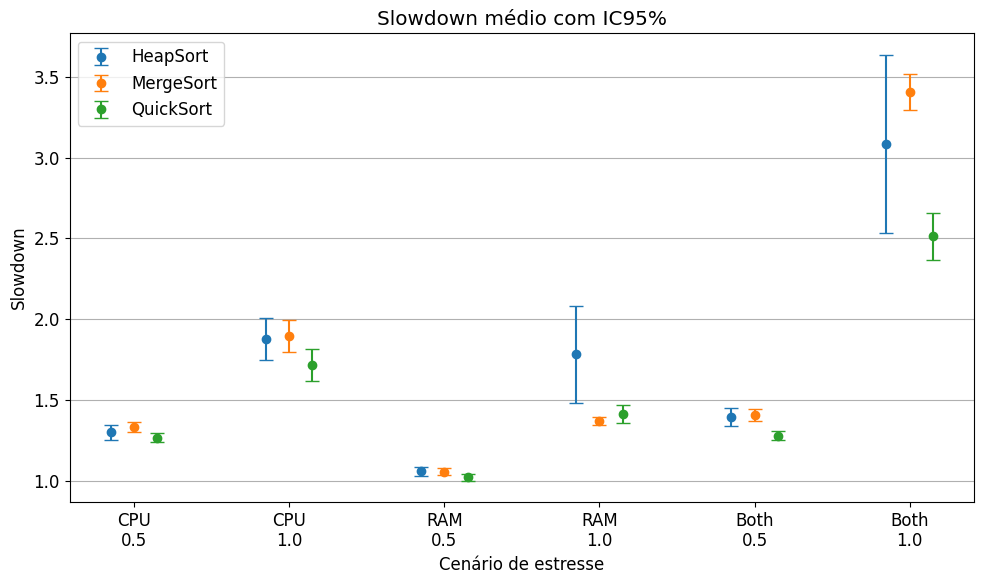

In [9]:
# Tempo médio sem estresse para cada algoritmo e tipo de vetor
baseline = (
    all_data[all_data["stress"] == "none"]
    .groupby(["algorithm", "vector_type"])["time_ms"]
    .mean()
)

slow = all_data[all_data["stress"] != "none"].copy()

slow["baseline"] = slow.apply(
    lambda r: baseline[(r["algorithm"], r["vector_type"])],
    axis=1
)

slow["slowdown"] = slow["time_ms"] / slow["baseline"]

slow_ic = (
    slow
    .groupby(["algorithm", "stress", "carga"])["slowdown"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)
ordem = [
    ("cpu", 0.5),
    ("cpu", 1.0),
    ("ram", 0.5),
    ("ram", 1.0),
    ("both", 0.5),
    ("both", 1.0)
]

slow_ic["ordem"] = slow_ic.apply(
    lambda r: ordem.index((r["stress"], r["carga"])),
    axis=1
)

slow_ic = slow_ic.sort_values("ordem")

plt.figure(figsize=(10,6))

algoritmos = ["HeapSort", "MergeSort", "QuickSort"]
offsets = [-0.15, 0, 0.15]

x = np.arange(len(ordem))

for alg, offset in zip(algoritmos, offsets):

    dados = slow_ic[slow_ic["algorithm"] == alg]

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",
        capsize=5,
        label=alg
    )

plt.xticks(
    x,
    [
        "CPU\n0.5",
        "CPU\n1.0",
        "RAM\n0.5",
        "RAM\n1.0",
        "Both\n0.5",
        "Both\n1.0"
    ]
)

plt.ylabel("Slowdown")
plt.xlabel("Cenário de estresse")
plt.title("Slowdown médio com IC95%")
plt.grid(axis="y")
plt.legend()

plt.tight_layout()
plt.show()

É possível ver bem como cada algoritmo resiste aos estresses. O algoritmo mais resiliente é o do Quicksort (visto em em ambos both ele apresenta menores valores, apesar que no both 1.0 não é possível afirmar que ele tem menos slowdown do que o Heap).

Heapsort apresenta muita variabilidade em estresses altos, indicando que em alguns vetores sua qualidade degenera muito e em outros ele se mantém igual ou melhor que os outros dois algoritmos de sorting. A grande exceção é RAM 1.0 onde Heapsort é o que mais degenera de todos, indicando que uma RAM cheira atrapalha muito o funcionamento do Heapsort.

Mergesort consegue aguentar pressões indivudais na CPU e na RAM, mas quando existem em ambas degenera rapidamente e no caso Both 1.0 chega a slowdowns de 3.5 comparados aos 2.5 do Quicksort. Isso indica que com CPU e RAM ocupado o processo de troca entre vetor auxiliar e principal.

Nota-se que todos algoritmos degeneram fortemente com Both 1.0

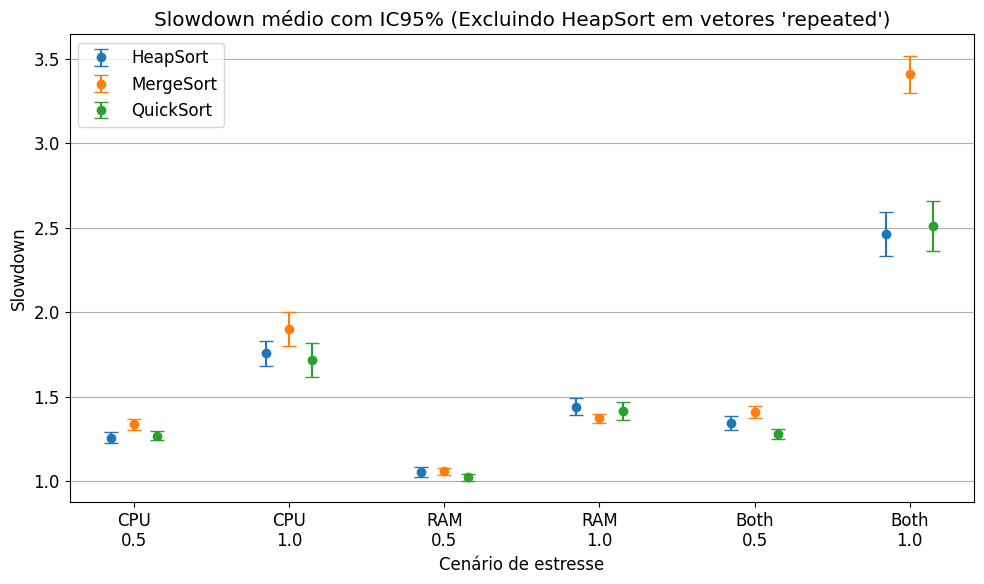

In [10]:
filtro_remover = (all_data["algorithm"] == "HeapSort") & (all_data["vector_type"] == "repeated")
df_filtrado = all_data[~filtro_remover].copy()

baseline = (
    df_filtrado[df_filtrado["stress"] == "none"]
    .groupby(["algorithm", "vector_type"])["time_ms"]
    .mean()
    .rename("baseline")
)


slow = df_filtrado[df_filtrado["stress"] != "none"].copy()

slow = slow.merge(baseline, on=["algorithm", "vector_type"], how="left")

slow["slowdown"] = slow["time_ms"] / slow["baseline"]

slow_ic = (
    slow
    .groupby(["algorithm", "stress", "carga"])["slowdown"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)

ordem_cenarios = [
    ("cpu", 0.5),
    ("cpu", 1.0),
    ("ram", 0.5),
    ("ram", 1.0),
    ("both", 0.5),
    ("both", 1.0)
]

ordem_mapping = {cenario: idx for idx, cenario in enumerate(ordem_cenarios)}

slow_ic["ordem"] = [ordem_mapping[(s, c)] for s, c in zip(slow_ic["stress"], slow_ic["carga"])]

plt.figure(figsize=(10,6))

algoritmos = ["HeapSort", "MergeSort", "QuickSort"]
offsets = [-0.15, 0, 0.15]

for alg, offset in zip(algoritmos, offsets):
    dados = slow_ic[slow_ic["algorithm"] == alg]
    
    plt.errorbar(
        dados["ordem"] + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",
        capsize=5,
        label=alg
    )

x = np.arange(len(ordem_cenarios))
plt.xticks(
    x,
    [
        "CPU\n0.5",
        "CPU\n1.0",
        "RAM\n0.5",
        "RAM\n1.0",
        "Both\n0.5",
        "Both\n1.0"
    ]
)

plt.ylabel("Slowdown")
plt.xlabel("Cenário de estresse")
plt.title("Slowdown médio com IC95% (Excluindo HeapSort em vetores 'repeated')")
plt.grid(axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Removendo a exceção (Heapsort com vetor repeated), fica muito mais claro as tendências. Vemos que Heapsort e Quicksort tem essencialmente a mesma resistência a estresses e somente Mergesort tem comportamento diferente quando sob estresse dos demais

## 4. Eficiência energética por Comparação

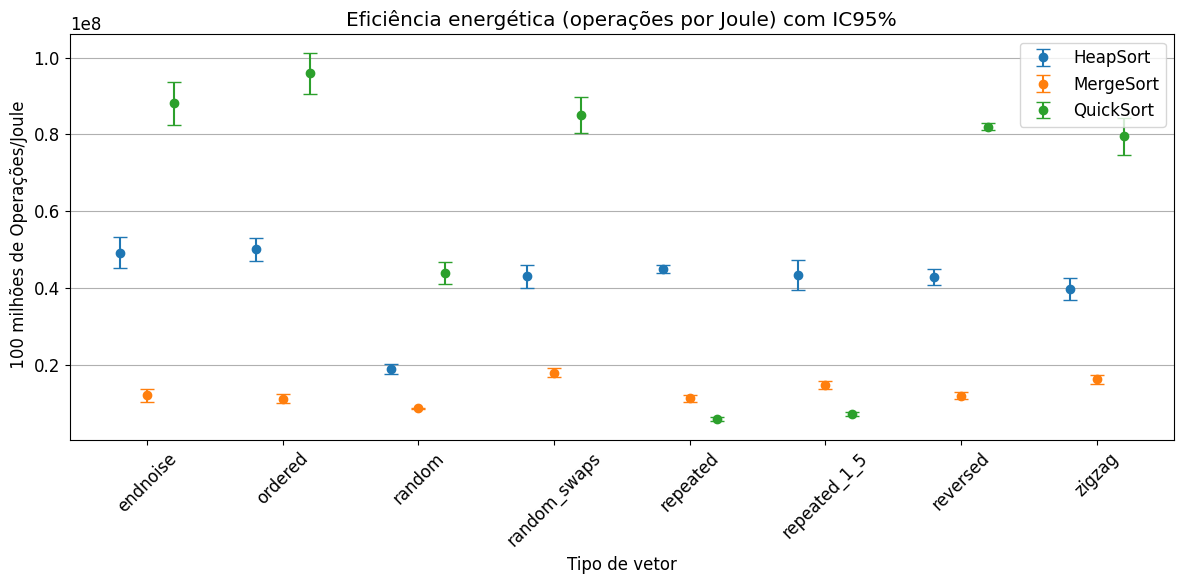

In [14]:
none = all_data[all_data["stress"] == "none"].copy()
none["operacoes_por_joule"] = (
    (none["comparisons"] + none["swaps"]) / none["energy_j"]
)

eficiencia = (
    none
    .groupby(["algorithm","vector_type"])["operacoes_por_joule"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)
plt.figure(figsize=(12,6))

algoritmos = ["HeapSort","MergeSort","QuickSort"]
offsets = [-0.2,0,0.2]

vetores = eficiencia["vector_type"].unique()
x = np.arange(len(vetores))

for alg, offset in zip(algoritmos, offsets):

    dados = (
        eficiencia[eficiencia["algorithm"] == alg]
        .set_index("vector_type")
        .loc[vetores]
        .reset_index()
    )

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",
        capsize=5,
        label=alg
    )

plt.xticks(x, vetores, rotation=45)

plt.ylabel(" 100 milhões de Operações/Joule")
plt.xlabel("Tipo de vetor")
plt.title("Eficiência energética (operações por Joule) com IC95%")

plt.grid(axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Possível ver facilmente a degeneração do quicksort nos casos repeated e repeated_1_to_5 que demora mais tempo fazendo menos comparações, resultando em tempo perdido.

Heapsort é extremamente consistente, mas faz menos comparações que Quicksort. Tendo apenas piora no caso Random.

Mergesort naturalmente faz menos comparações, devido a sua maneira de ordenar, gasta mais recursos trocando entre vetores auxiliares do que fazendo comparações

## 5. Eficiência Temporal

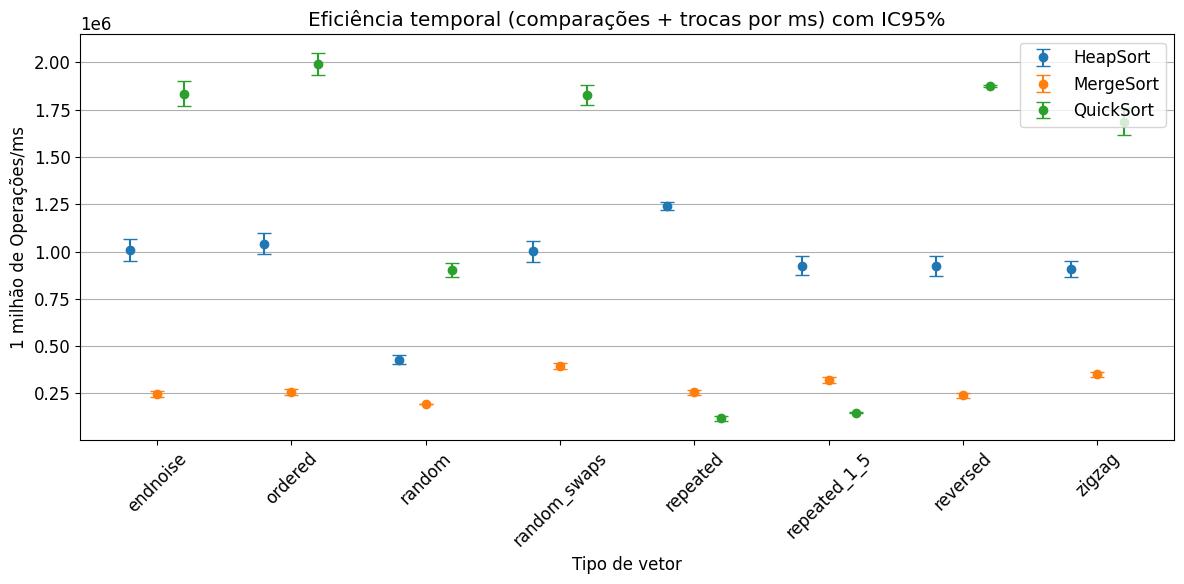

In [12]:
none["operacoes"] = (
    none["comparisons"] + none["swaps"]
)

none["operacoes_por_ms"] = (
    none["operacoes"] / none["time_ms"]
)
ef_temp = (
    none
    .groupby(["algorithm", "vector_type"])["operacoes_por_ms"]
    .apply(media_ic)
    .unstack()
    .reset_index()
)
plt.figure(figsize=(12,6))

algoritmos = ["HeapSort", "MergeSort", "QuickSort"]
offsets = [-0.2, 0, 0.2]

vetores = sorted(ef_temp["vector_type"].unique())
x = np.arange(len(vetores))

for alg, offset in zip(algoritmos, offsets):

    dados = (
        ef_temp[ef_temp["algorithm"] == alg]
        .set_index("vector_type")
        .loc[vetores]
        .reset_index()
    )

    plt.errorbar(
        x + offset,
        dados["media"],
        yerr=dados["ic"],
        fmt="o",
        linestyle="none",
        capsize=5,
        label=alg
    )

plt.xticks(x, vetores, rotation=45)

plt.ylabel("1 milhão de Operações/ms")
plt.xlabel("Tipo de vetor")
plt.title("Eficiência temporal (comparações + trocas por ms) com IC95%")

plt.grid(axis="y")
plt.legend()

plt.tight_layout()
plt.show()

Mesmo visto no gráfico anterior, Mergesort fica ainda mais inefetivo pois não realiza swaps.

## 5. Ranking por Estresse

In [13]:
# Média do tempo por configuração
ranking = (
    all_data
    .groupby(["vector_type", "stress", "carga", "algorithm"])["time_ms"]
    .mean()
    .reset_index()
)

# Seleciona o algoritmo mais rápido em cada cenário
ranking = (
    ranking
    .loc[
        ranking.groupby(["vector_type", "stress", "carga"])["time_ms"].idxmin()
    ]
    .sort_values(["vector_type", "stress", "carga"])
)

ranking.rename(columns={
    "algorithm": "Melhor algoritmo",
    "time_ms": "Tempo médio (ms)"
}, inplace=True)

ranking

,vector_type,stress,carga,Melhor algoritmo,Tempo médio (ms)
2,endnoise,both,0.5,QuickSort,489.83680
5,endnoise,both,1.0,QuickSort,945.98100
8,endnoise,cpu,0.5,QuickSort,471.23840
11,endnoise,cpu,1.0,QuickSort,682.78480
14,endnoise,none,0.0,QuickSort,377.17340
17,endnoise,ram,0.5,QuickSort,382.45440
20,endnoise,ram,1.0,QuickSort,566.87000
23,ordered,both,0.5,QuickSort,331.11960
26,ordered,both,1.0,QuickSort,734.58920
29,ordered,cpu,0.5,QuickSort,343.58560
